# Project Final Report

### Due: Midnight on April 27th (2-hour grace period) — 50 points  

### No late submissions will be accepted.


## Overview

Your final submission consists of **two components**:


### 1. Team Final Report Notebook [50 pts]

Complete all sections of this notebook to document your final decisions, results, and broader context.

You will write a **technical report** following standard conventions. Useful references include:
- [CMU guide to structure](https://www.stat.cmu.edu/~brian/701/notes/paper-structure.pdf)
- [Data science report example](https://www.projectpro.io/article/data-science-project-report/620)
- The Checklist in this week’s Blackboard Lesson (aligned with HOML)

Your audience is **technically literate but unfamiliar with your work**—for example, your manager or other data scientists. Your report should be clear, precise, and well-organized, combining explanation, visualizations, and interpretation.

This Final Report is distinct from Milestone 2:

- **Milestone 2** serves as a repository of your working code and experiments  
- **This Final Report** presents a clear, structured summary of your project for a professional audience  

> **Important:**
> - Do **not** assume that readers of this report are familiar with Milestone 2. Your report should stand on its own.
> - Do not include full code or code cells in this notebook. All code was submitted in Milestone 2. This report should focus on explanation, results, and interpretation.
> - **Do not add, delete, or move cells in this notebook.** Each answer must be written entirely within its assigned Markdown cell.
> - All answers should be inserted directly under the appropriate `Answer:` prompt. Delete the sentence "Replace this sentence with your answer" and replace it with your response.
> - You may use any appropriate Markdown formatting (paragraphs, lists, tables, inserted graphics, LaTeX, etc.).
> - Submit this notebook as a group via your team leader’s Gradescope account.


### 2. Individual Assessment [0 points]

Each team member must **individually** complete the Final Project Individual Assessment Form (similar to Milestone 1), sign it, and upload it via their own Gradescope account.

**Due:** May 5th @ 2:00 AM



## Submission Checklist

- Final Report Notebook — submitted by team leader  
- Individual Assessment Form — submitted by each team member  



## 1. Executive Summary [4 pts]

Write a 300–400 word executive summary for a **non-technical audience**, such as business stakeholders in a real estate company.

Your summary should explain:
- the objective of the project
- key insights about the data
- the most important findings, including a plain-language description of model performance
- a clear recommendation or takeaway

Avoid technical detail and jargon. Focus on what matters and why. 

**1.1 Answer:**  

Our team set out to answer a practical question: can we use a property's physical characteristics and location to reliably predict its assessed tax value? If so, this would allow our company to generate fast, data-driven property valuations at scale, reducing our dependence on expensive and time-consuming manual appraisals.

We worked with a dataset of approximately 77,400 residential properties, each described by dozens of features including square footage, bedroom and bathroom counts, lot size, building quality, year built, and geographic location. After cleaning the data and testing multiple approaches, we found that the strongest drivers of assessed value are total square footage, the number of bedrooms and bathrooms, the age of the property, and its location. These align closely with the factors that human appraisers already consider, which gives us confidence that the model is grounded in sound real estate logic.

We tested three different modeling approaches ranging from simple to complex. Our best-performing model predicts a property's assessed tax value with an average error of approximately $161,000. While this margin of error is meaningful in dollar terms, it is consistent across both the data the model trained on and a separate set of properties it had never seen before, which tells us the model is reliable and not just memorizing patterns from the training data.

The model performs well for the majority of standard-priced homes, where predictions cluster tightly around actual values. However, it struggles with multi-million-dollar luxury properties, where it consistently underestimates the assessed value. This is because these high-end homes are rare in the dataset, and the model lacks the features needed to distinguish them from other large properties, such as renovation status, waterfront views, or school district quality.

Our recommendation is to deploy this model as a first-pass valuation tool for standard residential properties, where it can handle the bulk of routine assessments quickly and affordably. For properties above a defined value threshold, the model's estimate should be flagged for manual review by a human appraiser. To improve accuracy on high-value homes over time, we recommend investing in richer data sources that capture property condition, nearby amenities, and neighborhood desirability. 

## 2. Introduction [3 pts]

Introduce the topic, context, and goals of your project.

You may imagine that this project was completed for a **real estate company with a small in-house data science team**.

Include all of the following:

- Clearly introduce the topic and context of your project
- Describe the problem you are addressing (the problem statement) and the overall motivation for solving it
- Clearly state the objectives and goals of your analysis (as different from the motivation)

**2.1 Answer:**  

Accurate property valuation is central to nearly every function of a real estate business, from setting competitive listing prices to advising buyers, managing investment portfolios, and assessing risk on mortgage applications. Traditionally, property valuations rely on manual appraisals that are time-consuming, expensive, and inconsistent across appraisers. For a company operating at scale, this creates a bottleneck: the business needs fast, reliable estimates for thousands of properties, but the manual process can only handle a fraction of that volume.

This project addresses a straightforward question: can we use the physical and geographic characteristics of a property to predict its assessed tax value with sufficient accuracy to support business decision-making? If so, an automated valuation model could supplement or even replace manual appraisals for routine use cases, freeing up resources for situations that require human judgment.

Our objective was to build a regression model that minimizes prediction error on assessed property values, measured in dollars. Specifically, we aimed to explore multiple modeling approaches, identify which property features drive value most strongly, and deliver a final model that generalizes reliably to properties the model has not seen before. The goal was not to eliminate human appraisers entirely, but to provide a scalable first-pass estimate that the business can act on with confidence.

## 3. Data Description [3 pts]

Describe the dataset used in your analysis.

Include:
- the source of the dataset
- the number of observations (samples) and features
- the types of variables
- the target variable
- missing values or other important issues in the raw data

**3.1 Answer:**  

The dataset used in this analysis is a subset of the Zillow Prize dataset, originally hosted on Kaggle as part of a 2017 competition to improve Zillow's home value estimates. It contains approximately 77,400 property records with 54 features describing the physical characteristics, location, and tax assessment details of residential properties.

Features span several variable types. Continuous numeric variables include property size measurements (e.g., `calculatedfinishedsquarefeet`, `lotsizesquarefeet`, `garagetotalsqft`), geographic coordinates (`latitude`, `longitude`), and the target variable itself. Discrete numeric variables include counts such as `bedroomcnt`, `bathroomcnt`, and `poolcnt`. Categorical variables include identifiers for property type (`propertylandusetypeid`), heating system (`heatingorsystemtypeid`), building quality (`buildingqualitytypeid`), and geographic region (`regionidcity`, `regionidzip`, `fips`). A small number of binary flag variables indicate the presence of amenities like hot tubs or fireplaces.

The target variable is `taxvaluedollarcnt`, representing the total assessed value of the property in dollars. Its distribution is heavily right-skewed, with most properties clustered around a median value and a long tail of high-value luxury properties.

Missing data was a significant issue in the raw dataset. Several features had over 95% of their values missing (e.g., `buildingclasstypeid` at 99.98%, `architecturalstyletypeid` at 99.73%) and were ultimately dropped. Amenity-related features like `poolcnt` and `garagecarcnt` had 67–79% missing values, but these were interpretable as the absence of the amenity and were imputed with zero. Thirty-five rows had a null target value and were removed entirely.

## 4. Methodology (What you did, and why) [20 pts]

Focus on the **process and your reasoning**, not the results.

Note: Each subsection (e.g., 4.1, 4.2, etc.) must be answered in its own Markdown cell.  Each subsection is worth 5 points. 

### 4.1 Analytical Framework

Describe your overall approach.

Include:
- your overall framework
- use of validation curves
- choice of MAE or RMSE (as appropriate) as the primary error metric

**4.1 Answer:**  
 
Three baseline models were created using default parameters: Ridge Regression, Random Forest, and Gradient Boosting. This comparison was designed to test whether tree-based models would outperform a linear baseline, which is consistent with the expectation that property values depend on complex relationships between features like square footage and location. Formal validation curves were not generated at the baseline stage as the primary goal was model comparison, not hyperparameter tuning. However, the standard deviations from repeated cross-validation served a similar diagnostic purpose: Random Forest's low CV standard deviation indicated stable performance across folds with no strong evidence of overfitting. If the model had shown high variance, validation curves would have been used to identify optimal complexpty parameters like max_depth. MAE was selected as the primary error metric as it expresses prediction error in direct dollar terms, which is interpretable for real estate stakeholders. Additionally, MAE is more robust to outlier sale prices than RMSE, a relevant consideration for housing data that may include luxury properties or distressed sales at the extremes.

### 4.2 Data Cleaning and Preprocessing

Describe how you prepared the data.

Include:
- issues in the raw data
- handling of missing values, outliers, inconsistencies
- key decisions and why
- what worked and what did not work

**4.2 Answer:**  

Five unsuitable features were dropped: parcelid (unique identifier, no predictive signal), assessmentyear (zero variance, only one unique value), rawcensustractandblock (redundant with censustractandblock), and two high-cardinality text fields (propertyzoningdesc with 1,907 unique values, propertycountylandusecode) that were impractical to encode. Features with >50% missing values were dropped (26 features). Beyond this threshold, imputation introduces more noise than signal. Three amenity columns (poolcnt, garagecarcnt, garagetotalsqft) were exceptions. NaN almost certainly means no pool or garage, so 0 is the correct imputed value. Rows with null targets or >50% missing features were removed. Extreme target outliers used a wide IQR fence (multiplier of 5.0 rather than 1.5) to retain legitimate luxury properties. Remaining missing values used three strategies: amenity counts to 0, categorical IDs to mode, and all other numeric columns to median (robust to the right-skew observed in Part 2). Median imputation worked well. Mean imputation would have failed due to outlier distortion, and one-hot encoding high-cardinality text was impractical without domain expertise.

### 4.3 Feature Engineering

Describe your feature engineering.

Include:
- transformations or new features
- why you created them
- which were useful or not useful
- what worked and what did not work

**4.3 Answer:**  

No new feature transformations were created beyond the original dataset. The focus was on feature selection rather than engineering new variables. Two selection methods were tested" forward selection (using Linear Regression as the estimator) and tree-based selection (using Random Forest importance with a median threshold). Forward selection picked 5 features. Tree-based selection kept features above median importance.
These methods were tested to reduce dimensionality and potentially improve model generalization by removing noisy or redundant features.
Feature selection did not improve model performance. For all three models (Linear Regression, Random Forest, Gradient Boosting), the full feature set achieved the lowest MAE compared to both selection methods. Reducing features increased error slightly, meaning useful predictive information was lost.
Several features were consistently retained across methods: finishedsquarefeet12, latitude, longitude, regionidzip, and yearbuilt. The tree-based method also identified bathroomcnt, calculatedfinishedsquarefeet, lotsizesquarefeet, and regionidcity as important. Both geographic and property size variables were strong predictors.
Newly engineered features were not created, so none were selected. The most predictive signal came from original dataset variables. What worked: using the full feature set. What did not work: both forward selection and tree-based selection, as they reduced predictive accuracy across all three models.

### 4.4 Model Selection

Describe how you selected your model.

Include:
- models you tried and why
- how you evaluated generalization
- hyperparameter tuning
- how you chose the final model

**4.4 Answer:**  

Three models were tested: Ridge Regression (linear baseline), Random Forest (bagged trees), and Gradient Boosting (boosted trees). This allowed comparison between linear and tree-based approaches. Housing data typically contains nonlinear interactions, so tree-based models were expected to perform better.
Repeated cross-validation (5x5 folds) was used for baseline comparisons in Part 1. For hyperparameter tuning in Part 4, 3-fold cross-validation was used to speed up search. The final model was evaluated on a held-out test set to confirm generalization.
Random Forest was selected as the final model. It achieved the lowest CV MAE comapred to Gradient Boosting and Ridge. While Ridge had lower variance across folds, Random Forest's MAE was lower. The trade-off was interpretability for performance. Tree-based models are harder to explain to stakeholders, but the $25,000 gain in predictive accuracy justified the choice.
Log transformations and polynomial features were engineered in Milestone 1 to address right-skewness. After full modeling, these features did not improve performance. Tree-based models handle skewed data produced identical or slighly better CV scores, so engineered features were dropped to keep the pipeline simple.

## 5. Results and Evaluation (What you found, and how well it worked) [16 pts]

Focus on **results, evidence, and interpretation**.

Note: Each subsection (e.g., 5.1, 5.2, etc.) must be answered in its own Markdown cell. 

### 5.1 Model Performance (6 points)

Briefly interpret what your metrics mean in practical terms.

Include:
- key metrics (e.g., RMSE, $R^2$)
- comparison across models
- comparison of training vs validation/test performance

**5.1 Answer:**  
**Model Performance**

To evaluate our models, we used **Mean Absolute Error (MAE)**. In practical terms, MAE represents the average dollar amount our model's predicted tax value differs from the actual assessed tax value. For example, an MAE of $161,000 means the predictions are, on average, over or under the actual tax value by that amount.

**Comparison Across Models**

We evaluated the performance of three models: Ridge Regression, Gradient Boosting, and Random Forest. 

| Model | Average Validation MAE | MAE Variation (± Std Dev) |
| :--- | :--- | :--- |
| **Ridge Regression** | $186,353 | $541 |
| **Gradient Boosting** | $164,482 | $1,191 |
| **Random Forest** | **$161,149** | **$1,250** |

Unsurprisingly, **Ridge Regression** performed the worst. Because it is a linear model, it struggled to capture the complex relationships in the dataset (e.g., how the combination of location and square footage affects price). **Gradient Boosting** performed significantly better, reducing the error by approximately $22,000. **Random Forest** performed the best. Tree-based models partition data into groups and excel at capturing the complex, non-linear patterns present among the features.

We also considered the Standard Deviation (Std Dev) for these results. Standard deviation measures how much the error fluctuated when testing the models on different folds of the data. A lower Std Dev means the model’s performance is highly stable. Ridge Regression is the most stable (fluctuating by only $541), which is typical for linear models. While Random Forest has the highest fluctuation at $1,250, this is relatively small compared to the $161,149 average error (less than a 1% swing). This small amount of additional fluctuation in exchange for a massive $25,000 improvement in overall accuracy is a reasonable trade-off.

**Training vs. Validation/Test Performance**

To ensure that our best Random Forest model would perform well on new, unseen real-world data, we compared its performance on the training data against a held-out test set.

| Data Split | MAE |
| :--- | :--- |
| **Cross-Validation (Training Set)** | $161,790 |
| **Test Set** | $161,026 |

The test error is nearly identical to (and actually slightly lower than) the validation error. This is strong evidence that our model generalizes well to new, unseen data. While the model does struggle to capture the patterns of extreme outliers (to be discussed in Section 5.3), it successfully predicted the target variable for the vast majority of standard homes without simply memorizing the training data.

### 5.2 Visualizations (5 points)

Graphics should be made as screenshots and dragged into the Markdown cell. Do NOT add code cells to create graphics. Each visualization must be clearly labeled and explained in the text.

Include:
- relevant plots with titles and labels
- explanation of what each plot shows
- why each visualization matters

**5.2 Answer:**  

#### Figure 1

This chart ranks the top 20 property features based on their “F-Statistic.” An F-Statistic is a mathematical score that measures how well that feature explains the dataset's variance. In other words, it indicates how strongly a specific feature is linked to the home’s price. The longer the bar, the stronger the relationship. The color of the bars represents the “p-value.” A p-value measures the probability of the relationship occurring purely by chance. The lower the p-value, the better.  As shown in Figure 1, all the bars are dark red, indicating very low p-values. This provides mathematical certainty that these top 20 features are truly driving the assessed tax values, rather than just being a random fluke.

Ensemble models can sometimes feel like a “black box” to business leaders. Because these models aggregate the results of many decision trees, it is nearly impossible to explain why a certain prediction was made. To combat this lack of transparency, a feature importance chart visualizes which property features contributed the most towards the prediction-making. In this case, the chart confirms that the strongest predictors of a home’s value include total square footage (`finishedsquarefeet12`), the number of bedrooms and bathrooms (`bedroomcnt` and `bathroomcnt`), and age (`yearbuilt`).  Because these are the same focal points used in a manual home appraisal, these results give stakeholders confidence that our models are grounded in realistic real estate logic.

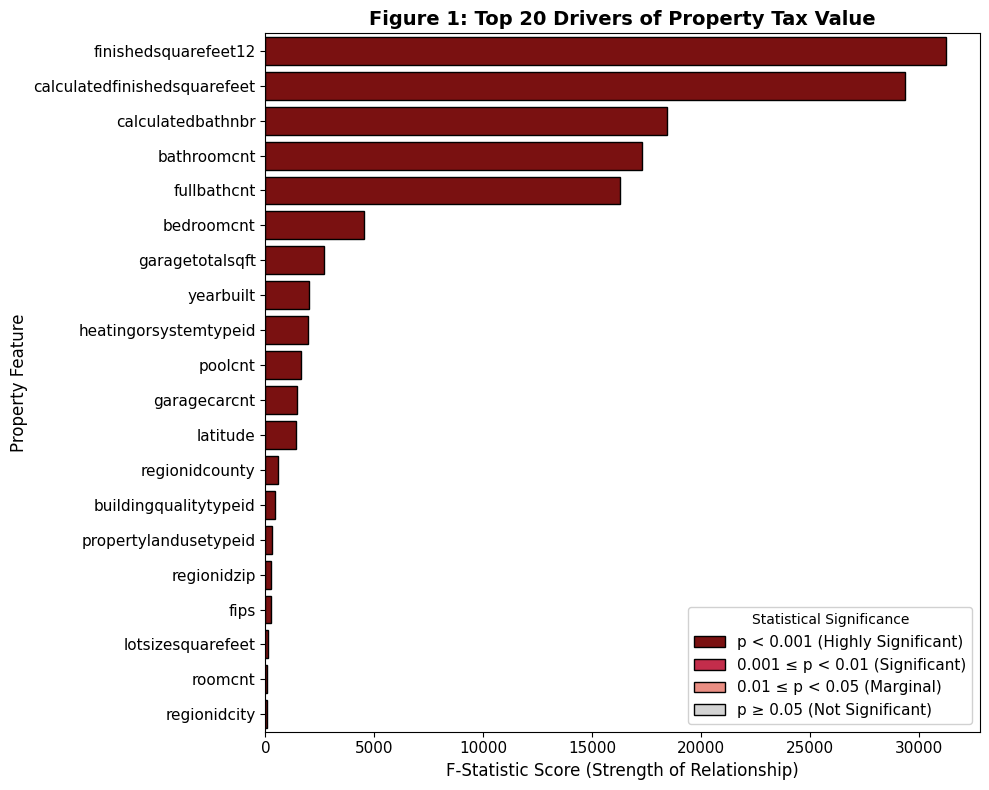

#### Figure 2

This scatter plot compares the actual assessed tax value of the properties (X-axis) against what our final Random Forest model predicted those values to be (Y-axis). The red dashed diagonal line represents where the actual and predicted values match exactly.

This chart provides a transparent visual of the model’s accuracy and shows us exactly where it struggles. While the model is highly accurate for standard-priced homes (where the dots cluster tightly around the red line), it tends to under-predict multi-million-dollar outliers (where the dots fall significantly below the red line). Identifying this specific weakness in the model allows us to confidently automate appraisals for standard-priced homes while setting up a system rule to flag luxury estates (e.g., where the predicted tax value exceeds a specific threshold) for a manual human review.

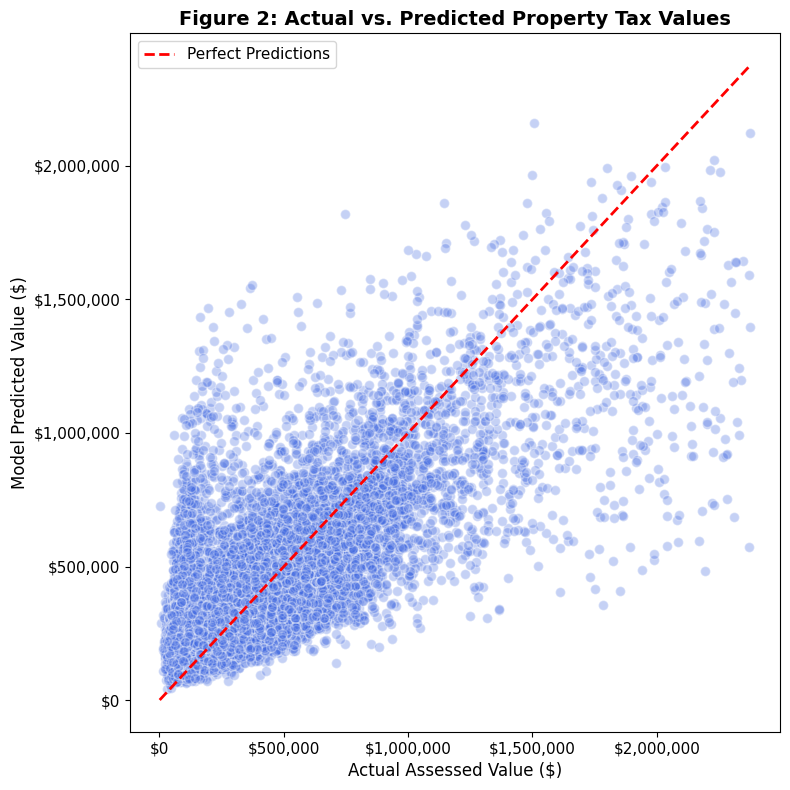

#### Figure 3

This bar chart compares the Mean Absolute Error (MAE) of all three models under two different scenarios: trained on the original raw dataset (blue bars) versus trained on a dataset containing engineered features like polynomials and log transformations (orange bars).

This visual suggests how the model development process can be made more efficient. It proves to stakeholders that spending computational power on such data transformations did not noticeably improve the models. Because the error rates are practically identical across both datasets, we can confidently drop the engineered features, making the final modeling pipeline simpler, faster, and more cost-effective without sacrificing predictive accuracy.

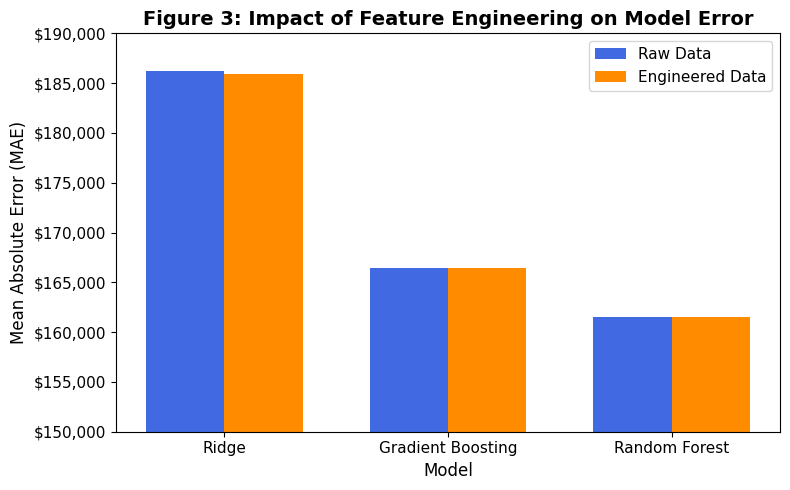

### 5.3 Error Analysis (5 points)

Include:
- patterns in residuals or prediction errors
- overprediction or underprediction
- outliers or unusual observations
- anything surprising or worth improving

**5.3 Answer:**

#### Patterns in Prediction Errors

Looking at the Actual vs. Predicted scatter plot (Figure 2), we can see a clear pattern in the model's prediction errors. The vast majority of properties are among the standard-priced homes clustered in the bottom-left corner, and these dots tightly hug the red “perfect prediction” line. However, as the actual tax value increases, the dots deviate further away from the red line. This means that the higher the tax value, the higher our model's error rate grows.

#### Overprediction vs. Underprediction

The most glaring issue with the model is how it handles unusually expensive properties (luxury homes or massive estates). On the far right side of the X-axis in Figure 2, there are homes with actual assessed values of several million dollars. Almost all of the dots for these properties fall significantly below the red line.

This indicates a strong tendency to under-predict high-value properties. This makes sense based on how the Random Forest algorithm works; it groups similar houses together and averages their prices. Because these ultra expensive homes are uncommon, their predicted tax values are diluted when the model averages them with less expensive homes that share similar characteristics like square footage or bedroom count.

#### Outliers

The extreme outliers in the dataset are these multi-million-dollar homes. Because they are so mathematically above the median home price, they heavily inflate the overall Mean Absolute Error (MAE). If we were to drop these outliers from the dataset before running the model, the baseline accuracy for the average home looks significantly stronger.

#### Surprises and Areas for Improvement

The fact that our final model struggles with luxury homes highlights a missing piece in our dataset. Currently, our features only describe the basic attributes of a house (square footage, bedroom and bathroom count, and general location).

To improve the model, we need more features that capture the quality and context of the property. For example:

- **Condition Status:** An outdated home and a newly renovated home with the same square footage and zip code are currently treated identically by the model.
- **Amenities:** Simple latitude/longitude coordinates do not capture amenities like a waterfront view, which is typically seen as a desirable attribute influencing property values.
- **School Distict Rating:** Incorporating local public school ratings would help the model account for neighborhood desirability, which is a major driver of real estate pricing.

## 6. Conclusion [4 pts]

Summarize your findings and implications.

Include all the following:

- Clearly state your main findings and how they address your original objectives
- Highlight any business or practical implications of your findings 
- Discuss the limitations and constraints of your analysis clearly and transparently
- Suggest potential improvements or future directions
- Conclude with a final recommendation addressing the business objective

**6.1 Answer:**  

Our primary objective was to build a regression model capable of predicting assessed property tax values from physical and geographic features. The final Random Forest model achieved a cross-validation MAE of approximately $161,149 and a test set MAE of $161,026, demonstrating reliable generalization to unseen data. This model outperformed both Gradient Boosting (CV MAE of $164,482) and Ridge Regression (CV MAE of $186,353), confirming that tree-based ensemble methods are better suited to capturing the complex, nonlinear relationships present in housing data.

From a business perspective, the model can serve as a scalable first-pass valuation tool. For the majority of standard-priced residential properties, predictions are closely aligned with actual assessed values. Automating these routine valuations would reduce the cost and turnaround time associated with manual appraisals, allowing human appraisers to focus their time on complex or high-value cases that require expert judgment.

Several limitations should be noted. The model consistently underpredicts the assessed value of luxury properties, as shown in the error analysis. This is driven by the rarity of such properties in the dataset and the absence of features that distinguish high-end homes from other large properties. The dataset also lacks information about property condition, renovation status, school district quality, and proximity to desirable amenities, all of which are known to influence real estate pricing. Additionally, the dataset reflects a single assessment year, so the model does not account for changes in market conditions over time.

Future work should focus on enriching the dataset with features that capture property quality and neighborhood context. Incorporating school district ratings, proximity to landmarks, and property condition indicators could meaningfully reduce prediction error on high-value homes. A separate model or rule-based filter for luxury properties may also be worth exploring, since these homes appear to follow different pricing patterns than the broader market.

We recommend deploying the current model for routine residential valuations while implementing a threshold-based flag for high-value properties that should be reviewed manually. This approach balances the efficiency gains of automation with the accuracy demands of the business.
